<a href="https://colab.research.google.com/github/Pavanishreebs/Handedness-Age-Analysis/blob/main/Handedness_Age_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# STEP 1: Upload both CSVs to Colab
from google.colab import files
uploaded = files.upload()


Saving lefthanded_data.csv to lefthanded_data.csv


In [ ]:
# STEP 2: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


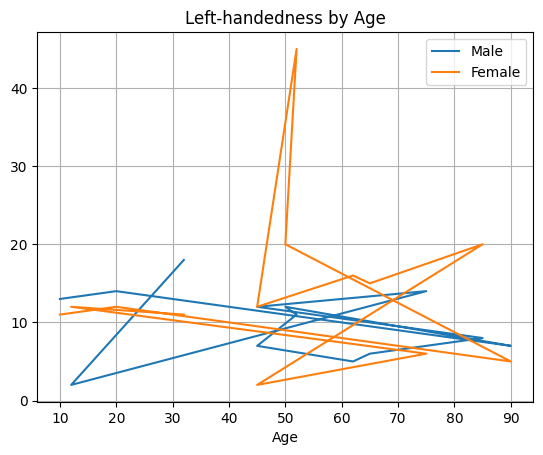

In [ ]:
# STEP 3: Load Handedness Data (Task 1)
lefthanded_data = pd.read_csv('lefthanded_data.csv')
lefthanded_data.plot(x='Age', y=['Male', 'Female'], title='Left-handedness by Age')
plt.grid(True)
plt.show()


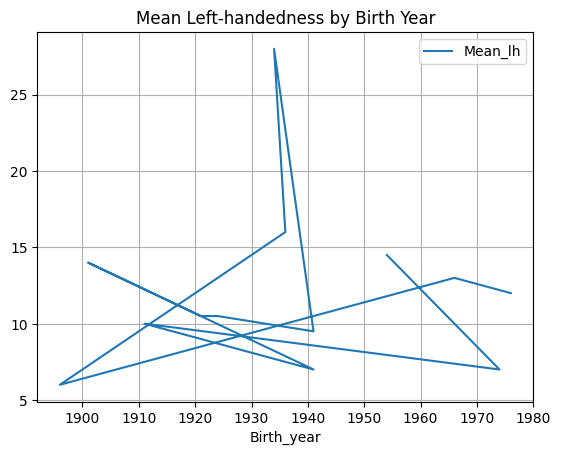

In [ ]:
# STEP 4: Add Birth Year & Mean (Task 2)
lefthanded_data['Birth_year'] = 1986 - lefthanded_data['Age']
lefthanded_data['Mean_lh'] = lefthanded_data[['Male', 'Female']].mean(axis=1)
lefthanded_data.plot(x='Birth_year', y='Mean_lh', title='Mean Left-handedness by Birth Year')
plt.grid(True)
plt.show()


In [ ]:
# STEP 5: Define P(LH | A) Function (Task 3)
def P_lh_given_A(age_of_death, study_year=1986):
    birth_year = study_year - age_of_death
    df = lefthanded_data.copy()
    lh_rate = np.interp(birth_year, df['Birth_year'], df['Mean_lh'])
    return lh_rate / 100


In [ ]:
# STEP 1: Upload both CSVs to Colab
from google.colab import files
uploaded = files.upload()

Saving death_distribution_data.csv to death_distribution_data (1).csv


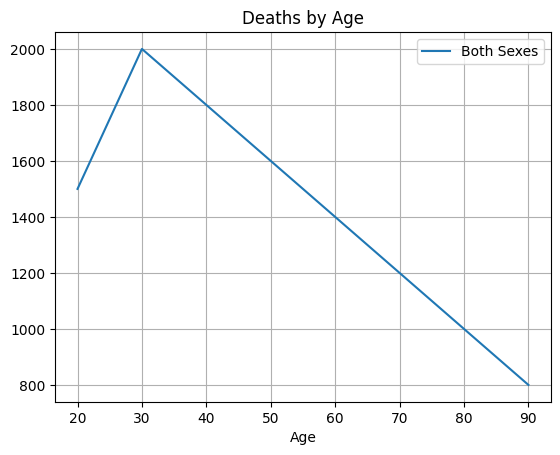

In [ ]:
# STEP 6: Load Death Distribution (Task 4)
death_distribution_data = pd.read_csv('death_distribution_data.csv', skiprows=[1]) # Changed: Removed sep='\t'
#If the file has a header in the first row after skipping, you might need to include header=0 in the parameters
death_distribution_data = death_distribution_data.dropna(subset=['Both Sexes'])
death_distribution_data.plot(x='Age', y='Both Sexes', title='Deaths by Age')
plt.grid(True)
plt.show()


In [ ]:
# STEP 7: Define P(LH) Function (Task 5)
def P_lh(study_year=1986):
    p_list = death_distribution_data.apply(
        lambda row: row['Both Sexes'] * P_lh_given_A(row['Age'], study_year), axis=1)
    total_deaths = death_distribution_data['Both Sexes'].sum()
    return p_list.sum() / total_deaths


In [ ]:
# STEP 8: Define P(A | LH) (Task 6)
def P_A_given_lh(study_year=1986):
    total_deaths = death_distribution_data['Both Sexes'].sum()
    P_A = death_distribution_data['Both Sexes'] / total_deaths
    P_LH = P_lh(study_year)
    P_LH_given_A = death_distribution_data['Age'].apply(lambda A: P_lh_given_A(A, study_year))
    P_return = (P_LH_given_A * P_A) / P_LH
    return P_return


In [ ]:
# STEP 9: Define P(A | RH) (Task 7)
def P_A_given_rh(study_year=1986):
    total_deaths = death_distribution_data['Both Sexes'].sum()
    P_A = death_distribution_data['Both Sexes'] / total_deaths
    P_LH = P_lh(study_year)
    P_RH = 1 - P_LH
    P_LH_given_A = death_distribution_data['Age'].apply(lambda A: P_lh_given_A(A, study_year))
    P_RH_given_A = 1 - P_LH_given_A
    P_return = (P_RH_given_A * P_A) / P_RH
    return P_return


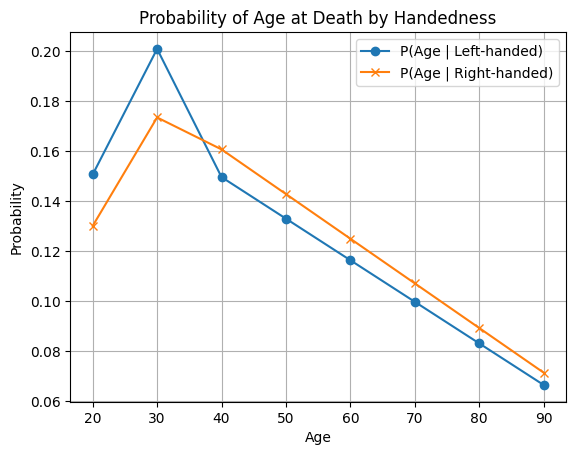

In [ ]:
# STEP 10: Plot P(A | LH) and P(A | RH) (Task 8)
P_A_LH = P_A_given_lh()
P_A_RH = P_A_given_rh()
ages = death_distribution_data['Age']

plt.plot(ages, P_A_LH, label='P(Age | Left-handed)', marker='o')
plt.plot(ages, P_A_RH, label='P(Age | Right-handed)', marker='x')
plt.title('Probability of Age at Death by Handedness')
plt.xlabel('Age')
plt.ylabel('Probability')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# STEP 11: Calculate Mean Age at Death (Task 9)
average_lh_age = np.nansum(ages * P_A_LH)
average_rh_age = np.nansum(ages * P_A_RH)
print("Average LH Age:", round(average_lh_age, 2))
print("Average RH Age:", round(average_rh_age, 2))
print("Difference:", round(average_rh_age - average_lh_age, 2))


Average LH Age: 48.28
Average RH Age: 49.95
Difference: 1.67


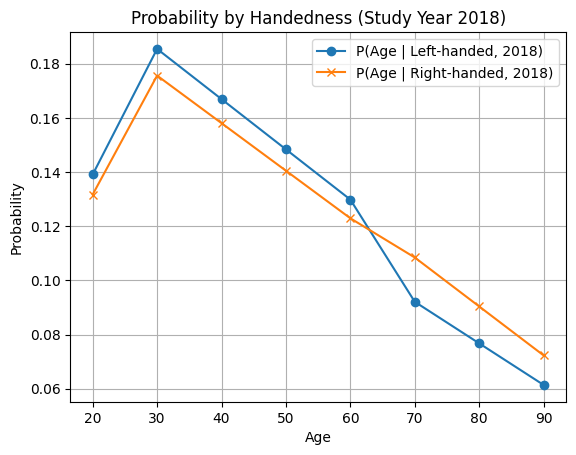

In [ ]:
# STEP 12: Repeat for Study Year 2018 (Task 10)
P_A_LH_2018 = P_A_given_lh(study_year=2018)
P_A_RH_2018 = P_A_given_rh(study_year=2018)

plt.plot(ages, P_A_LH_2018, label='P(Age | Left-handed, 2018)', marker='o')
plt.plot(ages, P_A_RH_2018, label='P(Age | Right-handed, 2018)', marker='x')
plt.title('Probability by Handedness (Study Year 2018)')
plt.xlabel('Age')
plt.ylabel('Probability')
plt.legend()
plt.grid(True)
plt.show()
